<a href="https://colab.research.google.com/github/stanley-kevin/DS_Hackthon_day1_Q2/blob/main/Hospital_Resource_Allocation_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hospital Resource Allocation Analysis

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Hospital_Department_Resource_Allocation_1200.csv')

# Display the first 5 rows of the DataFrame
print('First 5 rows of the dataset:')
display(df.head())

# Display information about the DataFrame to check data types and missing values
print('\nDataFrame Info:')
df.info()

First 5 rows of the dataset:


,Month,Department,Patient_Volume,Average_Treatment_Duration,Staff_Count,Equipment_Utilisation
0,2025-03,Neurology,117,77.1,15,71.99
1,2025-02,Cardiology,155,97.9,19,82.25
2,2025-06,Pediatrics,172,42.0,14,74.15
3,2025-08,Oncology,97,129.1,23,73.90
4,2025-11,Neurology,129,71.1,18,74.61



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Month                       1200 non-null   object 
 1   Department                  1200 non-null   object 
 2   Patient_Volume              1200 non-null   int64  
 3   Average_Treatment_Duration  1200 non-null   float64
 4   Staff_Count                 1200 non-null   int64  
 5   Equipment_Utilisation       1200 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 56.4+ KB


In [2]:
# Convert 'Month' column to datetime objects
df['Month'] = pd.to_datetime(df['Month'])

# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

# If duplicates exist, drop them (or decide on another strategy)
if duplicate_rows > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicate rows dropped. New number of rows: {len(df)}")

# Display the updated DataFrame info to confirm 'Month' type and new row count if duplicates were dropped
print('\nUpdated DataFrame Info:')
df.info()

Number of duplicate rows: 0

Updated DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Month                       1200 non-null   datetime64[ns]
 1   Department                  1200 non-null   object        
 2   Patient_Volume              1200 non-null   int64         
 3   Average_Treatment_Duration  1200 non-null   float64       
 4   Staff_Count                 1200 non-null   int64         
 5   Equipment_Utilisation       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 56.4+ KB


In [3]:
# Display descriptive statistics for numerical columns
print('Descriptive Statistics for Numerical Columns:')
display(df.describe())

# Display unique departments and their counts
print('\nUnique Departments and their Counts:')
display(df['Department'].value_counts())

Descriptive Statistics for Numerical Columns:


,Month,Patient_Volume,Average_Treatment_Duration,Staff_Count,Equipment_Utilisation
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2025-06-16 12:00:00,172.481667,67.523167,18.843333,76.139967
min,2025-01-01 00:00:00,83.000000,29.900000,11.000000,58.970000
25%,2025-03-24 06:00:00,131.000000,48.900000,16.000000,71.495000
50%,2025-06-16 00:00:00,159.000000,60.400000,18.000000,75.845000
75%,2025-09-08 12:00:00,213.250000,79.225000,21.000000,80.382500
max,2025-12-01 00:00:00,306.000000,141.000000,32.000000,94.130000
std,NaN,54.604206,24.904392,4.401318,6.437827



Unique Departments and their Counts:


,count
Department,
Neurology,150
Cardiology,150
Pediatrics,150
Oncology,150
Emergency,150
Orthopedics,150
Gynecology,150
General Medicine,150


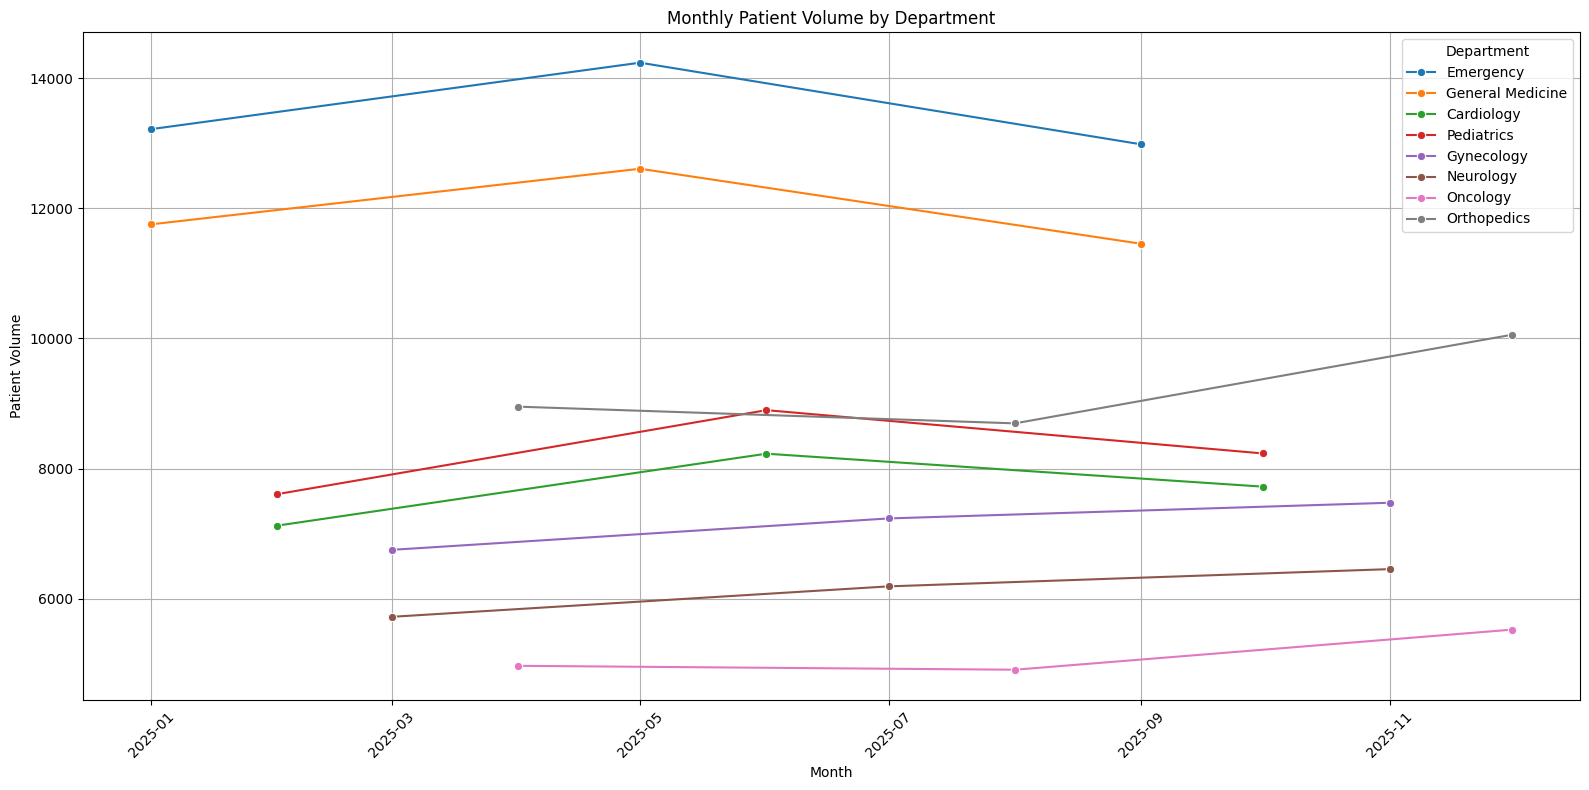

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract month and year for seasonal analysis
df['YearMonth'] = df['Month'].dt.to_period('M')

# Group by YearMonth and Department to see trends over time
monthly_department_data = df.groupby(['YearMonth', 'Department']).agg({
    'Patient_Volume': 'sum',
    'Staff_Count': 'sum',
    'Equipment_Utilisation': 'mean'
}).reset_index()

# Convert 'YearMonth' back to datetime for plotting
monthly_department_data['YearMonth'] = monthly_department_data['YearMonth'].dt.to_timestamp()

plt.figure(figsize=(16, 8))
sns.lineplot(data=monthly_department_data, x='YearMonth', y='Patient_Volume', hue='Department', marker='o')
plt.title('Monthly Patient Volume by Department')
plt.xlabel('Month')
plt.ylabel('Patient Volume')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
# Calculate Staff-to-Patient Ratio (lower is generally better, but context matters)
df['Staff_to_Patient_Ratio'] = df['Staff_Count'] / df['Patient_Volume']

# Calculate a proxy for overall capacity utilization. Higher values indicate higher utilization.
# We can consider 'Patient_Volume' and 'Average_Treatment_Duration' as demand,
# and 'Staff_Count' and 'Equipment_Utilisation' as capacity/usage.
# For a simple combined metric, let's consider Patient Volume * Treatment Duration as total patient load,
# and normalize by staff count and equipment utilization.
# A more direct approach could be to just use Equipment_Utilisation as it is a direct measure.
# Let's consider a simple weighted sum, or perhaps just focus on Equipment_Utilisation for now as it's provided.
# For a broader 'Capacity_Utilization' that reflects demand vs. resources, let's define it as:
# (Patient_Volume * Average_Treatment_Duration) / (Staff_Count * (100 / Equipment_Utilisation_as_percentage))
# Or more simply, let's assume 'Patient_Volume' is demand and 'Staff_Count' and 'Equipment_Utilisation' are aspects of capacity.
# A common way to think about utilization is 'output / capacity'.
# Let's create a simpler 'Demand_Load' and then relate it to 'Staff_Count' and 'Equipment_Utilisation'.

# Let's define Demand Load as Patient Volume * Average_Treatment_Duration (total treatment hours/minutes required)
df['Demand_Load'] = df['Patient_Volume'] * df['Average_Treatment_Duration']

# Let's consider a simplified 'Resource_Strain' metric
# Higher values mean more strain on resources
df['Resource_Strain'] = (df['Patient_Volume'] * df['Average_Treatment_Duration']) / (df['Staff_Count'] * df['Equipment_Utilisation'])


# Group by department to get average metrics
department_summary = df.groupby('Department').agg({
    'Patient_Volume': 'mean',
    'Average_Treatment_Duration': 'mean',
    'Staff_Count': 'mean',
    'Equipment_Utilisation': 'mean',
    'Staff_to_Patient_Ratio': 'mean',
    'Demand_Load': 'mean',
    'Resource_Strain': 'mean'
}).sort_values(by='Resource_Strain', ascending=False)

print('\nDepartment-wise Summary of Key Metrics:')
display(department_summary)


Department-wise Summary of Key Metrics:


,Patient_Volume,Average_Treatment_Duration,Staff_Count,Equipment_Utilisation,Staff_to_Patient_Ratio,Demand_Load,Resource_Strain
Department,,,,,,,
Orthopedics,184.673333,65.108667,17.080000,76.797933,0.093109,12034.189333,9.288653
Cardiology,153.813333,84.725333,18.086667,78.437667,0.118451,13015.869333,9.273274
Oncology,102.666667,120.081333,19.826667,69.165267,0.194601,12313.250667,9.072118
Neurology,122.426667,75.134667,15.013333,72.493667,0.123470,9199.332667,8.594775
Gynecology,143.046667,55.086667,14.906667,70.245133,0.104736,7879.986667,7.625720
Emergency,269.566667,54.965333,27.893333,86.094200,0.103877,14821.102000,6.201084
General Medicine,238.760000,45.104000,21.986667,81.376133,0.092459,10773.548667,6.059834
Pediatrics,164.900000,39.979333,15.953333,74.509733,0.097493,6589.108000,5.609318


/tmp/ipykernel_479/3954642005.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=department_summary.index, y='Resource_Strain', data=department_summary, palette='viridis')


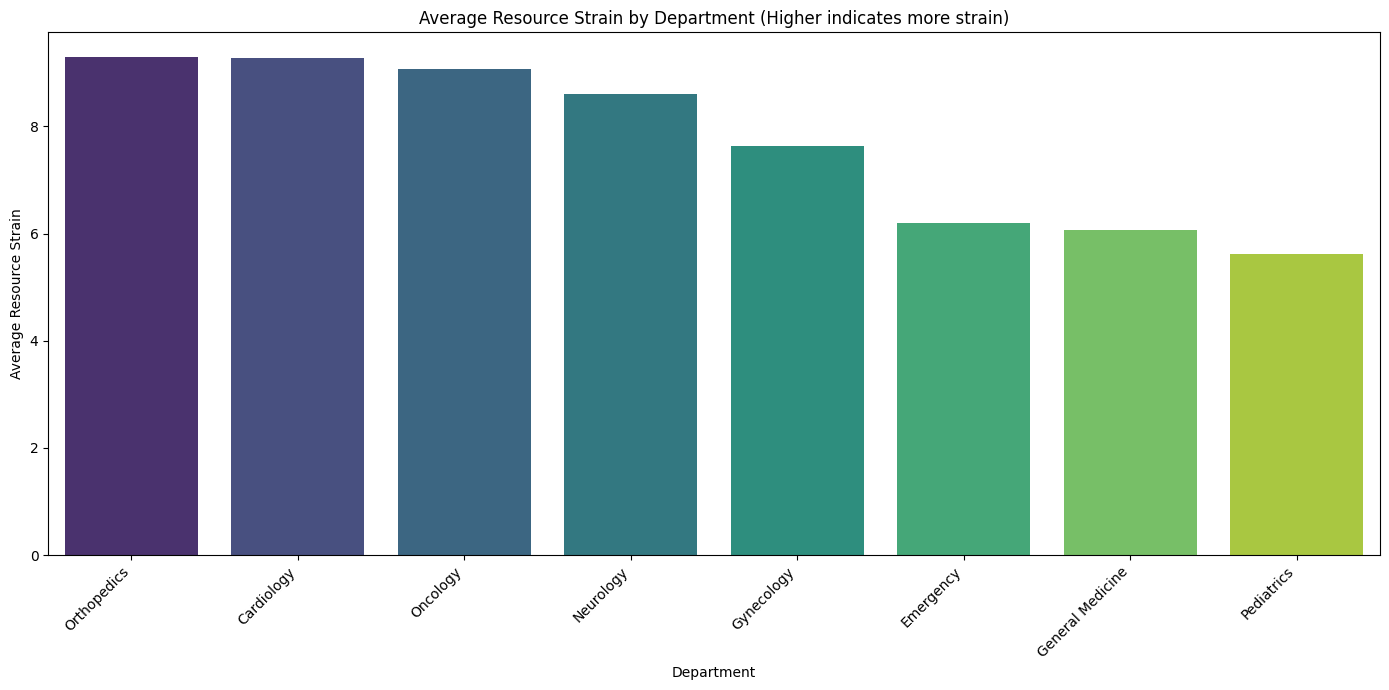

/tmp/ipykernel_479/3954642005.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=department_summary.index, y='Staff_to_Patient_Ratio', data=department_summary, palette='magma')


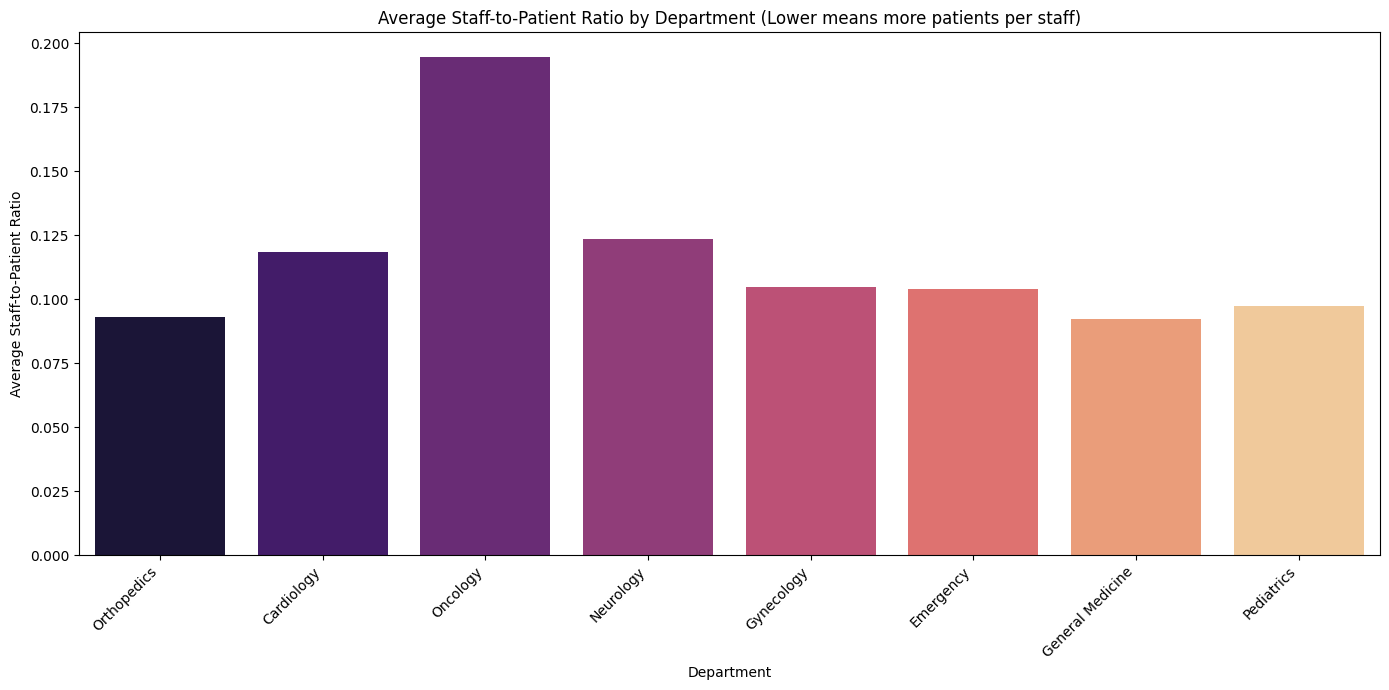

/tmp/ipykernel_479/3954642005.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=department_summary.index, y='Equipment_Utilisation', data=department_summary, palette='cividis')


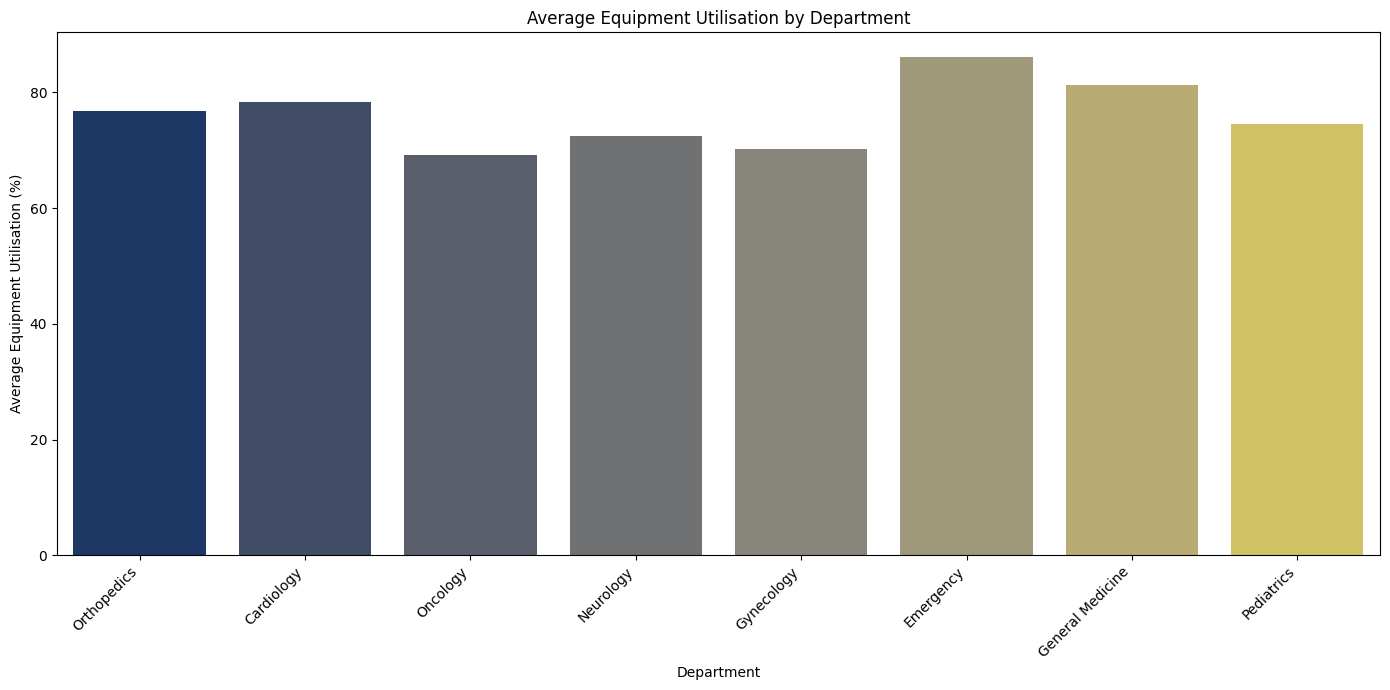

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization 2: Resource Strain by Department
plt.figure(figsize=(14, 7))
sns.barplot(x=department_summary.index, y='Resource_Strain', data=department_summary, palette='viridis')
plt.title('Average Resource Strain by Department (Higher indicates more strain)')
plt.xlabel('Department')
plt.ylabel('Average Resource Strain')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Visualization 3: Staff-to-Patient Ratio by Department
plt.figure(figsize=(14, 7))
sns.barplot(x=department_summary.index, y='Staff_to_Patient_Ratio', data=department_summary, palette='magma')
plt.title('Average Staff-to-Patient Ratio by Department (Lower means more patients per staff)')
plt.xlabel('Department')
plt.ylabel('Average Staff-to-Patient Ratio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Visualization 4: Equipment Utilisation by Department
plt.figure(figsize=(14, 7))
sns.barplot(x=department_summary.index, y='Equipment_Utilisation', data=department_summary, palette='cividis')
plt.title('Average Equipment Utilisation by Department')
plt.xlabel('Department')
plt.ylabel('Average Equipment Utilisation (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Prepare data for Random Forest model
# We'll predict Patient_Volume based on Month (features extracted), Department, Staff_Count, Equipment_Utilisation, Average_Treatment_Duration

# Feature Engineering from Month for seasonality
df['Month_num'] = df['Month'].dt.month
df['Day_of_week'] = df['Month'].dt.dayofweek # Although it's monthly data, this can capture weekly patterns if data represents first day of month
df['Day_of_year'] = df['Month'].dt.dayofyear

# Define features (X) and target (y)
X = df[['Month_num', 'Day_of_week', 'Day_of_year', 'Department', 'Average_Treatment_Duration', 'Staff_Count', 'Equipment_Utilisation']]
y = df['Patient_Volume']

# Define categorical and numerical features
categorical_features = ['Department']
numerical_features = ['Month_num', 'Day_of_week', 'Day_of_year', 'Average_Treatment_Duration', 'Staff_Count', 'Equipment_Utilisation']

# Create a column transformer for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

# Create a pipeline with the preprocessor and a Random Forest Regressor
model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model_pipeline.fit(X_train, y_train)

# Make predictions
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'\nRandom Forest Model Evaluation:')
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'R-squared (R2): {r2:.2f}')


Random Forest Model Evaluation:
Mean Absolute Error (MAE): 7.46
R-squared (R2): 0.97
